# Feature Importance, Variance & Satellite Imaging Parallax
### Elementary Algebra → Machine Learning → Earth Observation

> **The same proportion you learned in algebra**
> — $\frac{a}{b} = \frac{c}{d}$ —
> is the equation a satellite uses to measure depth from two photos.
> And the same variance formula from statistics tells you
> whether your machine learning model's feature rankings are trustworthy.

**Road map**

| § | Topic | Algebra connection |
|---|-------|--------------------|
| 1 | Elementary algebra review | variables, equations, ratios |
| 2 | Feature importance (what it is) | weighted sum, ranking |
| 3 | Variance of importance (is it stable?) | std deviation, bootstrap |
| 4 | Satellite parallax geometry | similar triangles, proportion |
| 5 | Ground sampling distance (GSD) | unit conversion, proportion |
| 6 | Putting it together: classify land cover from a satellite | all of the above |


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
sp.init_printing(use_latex='mathjax')
from IPython.display import display, Math

rng = np.random.default_rng(0)


---
## §1 — Elementary Algebra: The Building Blocks

Everything in this notebook flows from four ideas you can write on one line.

### 1.1 Variables and equations

A **variable** is a box that holds a number we don't know yet.

$$x + 3 = 7 \;\Longrightarrow\; x = 4$$

**Proportion** (equal ratios):

$$\frac{a}{b} = \frac{c}{d} \;\Longrightarrow\; ad = bc \quad \text{(cross-multiply)}$$

This is the satellite parallax equation in disguise.


In [2]:
x = sp.Symbol('x')

# Solve a linear equation
eq1 = sp.Eq(x + 3, 7)
sol1 = sp.solve(eq1, x)
print("Solve x + 3 = 7:"); display(sp.Eq(x, sol1[0]))

# Proportion: a/b = c/d -> solve for d
a, b, c, d = sp.symbols('a b c d', positive=True)
prop = sp.Eq(a/b, c/d)
d_sol = sp.solve(prop, d)[0]
print("\nProportion a/b = c/d, solve for d:")
display(sp.Eq(d, d_sol))
print("  Satellite use: a=baseline B, b=altitude H, c=disparity, d=depth")


Solve x + 3 = 7:


x = 4


Proportion a/b = c/d, solve for d:


    b⋅c
d = ───
     a 

  Satellite use: a=baseline B, b=altitude H, c=disparity, d=depth


### 1.2 Slope — rate of change

$$\text{slope} = m = \frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1}$$

In machine learning: slope = how much the output changes when one input changes.
That is exactly **feature importance**.

### 1.3 Variance — how spread out numbers are

$$\text{Var}(X) = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2, \qquad \sigma = \sqrt{\text{Var}(X)}$$

If the importance score of a feature varies a lot across different subsets of data,
we can't trust it — **high variance = unreliable ranking**.


In [3]:
# Algebra: variance from scratch with a tiny dataset
scores = np.array([3.0, 5.0, 4.0, 6.0, 2.0])
mean_s = scores.mean()
var_s  = ((scores - mean_s)**2).mean()
std_s  = var_s**0.5

print("Dataset:", scores)
print(f"Mean:     {mean_s:.2f}")
print(f"Variance: {var_s:.2f}  (average squared distance from mean)")
print(f"Std dev:  {std_s:.2f}  (back in original units)")

# SymPy version
x_i, x_bar, n_sym = sp.symbols('x_i xbar n', positive=True)
var_eq = sp.Eq(sp.Symbol('Var(X)'),
               sp.Sum((x_i - x_bar)**2, (sp.Symbol('i'), 1, n_sym)) / n_sym)
print("\nVariance formula:"); display(var_eq)


Dataset: [3. 5. 4. 6. 2.]
Mean:     4.00
Variance: 2.00  (average squared distance from mean)
Std dev:  1.41  (back in original units)

Variance formula:


           n            
          ___           
          ╲             
           ╲           2
           ╱   (xᵢ - x̅) 
          ╱             
          ‾‾‾           
         i = 1          
Var(X) = ───────────────
                n       

---
## §2 — Feature Importance: Which Input Matters Most?

A **random forest** builds many decision trees, each asking yes/no questions
about the inputs (features) to predict an output.

**Feature importance** = how much a feature *reduces uncertainty* (entropy)
averaged across all trees.

$$\text{importance}(j) = \frac{1}{T}\sum_{t=1}^T \sum_{\text{node } v \text{ splits on } j} \frac{n_v}{N}\,\Delta I_v$$

where $\Delta I_v$ = reduction in Gini impurity at node $v$, $n_v$ = samples at that node.

**Elementary algebra version**: it's a weighted average — features that appear
at the top of many trees (where more samples are affected) get higher weight.


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.inspection import permutation_importance

# Synthetic satellite land-cover dataset
# Features: NDVI, NIR reflectance, Red reflectance, Blue, SWIR, texture
feature_names = ['NDVI', 'NIR', 'Red', 'Blue', 'SWIR', 'Texture']
n_features = len(feature_names)

# 3 classes: forest=0, water=1, urban=2
X, y = make_classification(n_samples=1200, n_features=n_features,
                            n_informative=4, n_redundant=1, n_repeated=0,
                            n_classes=3, n_clusters_per_class=1,
                            random_state=42)

# Make NDVI and NIR the most informative (they are in real remote sensing)
X[:, 0] = X[:, 0] * 2   # NDVI amplified
X[:, 1] = X[:, 1] * 1.5 # NIR amplified

# Train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
print("Feature importances (mean decrease in Gini impurity):")
for name, imp in sorted(zip(feature_names, importances), key=lambda t: -t[1]):
    bar = "#" * int(imp * 200)
    print(f"  {name:<10}: {imp:.4f}  {bar}")


Feature importances (mean decrease in Gini impurity):
  SWIR      : 0.3258  #################################################################
  Blue      : 0.1753  ###################################
  NDVI      : 0.1660  #################################
  NIR       : 0.1466  #############################
  Texture   : 0.1392  ###########################
  Red       : 0.0471  #########


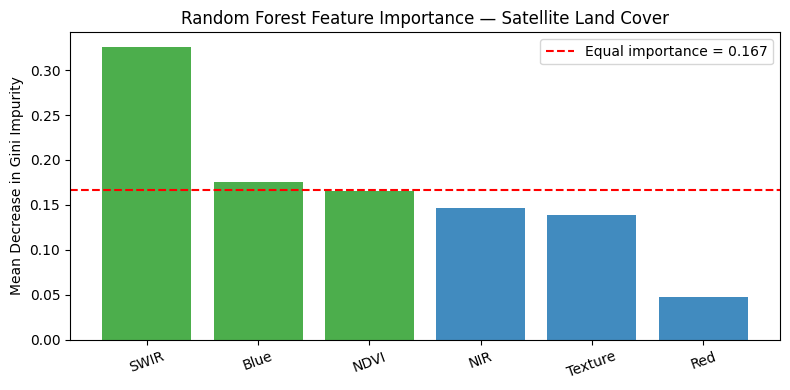

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.argsort(importances)[::-1]
colors = ['#2ca02c' if importances[i] > 0.15 else '#1f77b4' for i in idx]
ax.bar(range(n_features), importances[idx], color=colors, alpha=0.85)
ax.set_xticks(range(n_features))
ax.set_xticklabels([feature_names[i] for i in idx], rotation=20)
ax.set_ylabel('Mean Decrease in Gini Impurity')
ax.set_title('Random Forest Feature Importance — Satellite Land Cover')
ax.axhline(1/n_features, color='red', ls='--', lw=1.5,
           label=f'Equal importance = {1/n_features:.3f}')
ax.legend()
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=100); plt.show()


---
## §3 — Variance of Feature Importance: Can We Trust the Ranking?

A single importance number hides a problem: **it varies across different
training sets**. Bootstrap resampling reveals the true spread.

**Algorithm** (bootstrap):
1. Resample the dataset with replacement → fit a new forest → record importances
2. Repeat $B$ times
3. Compute mean and std of each feature's importance

If $\sigma_{\text{importance}}$ is large relative to the mean → **unstable ranking** → need more data.


In [6]:
from sklearn.utils import resample

B = 80   # bootstrap replicates
boot_importances = np.zeros((B, n_features))

for b in range(B):
    X_b, y_b = resample(X, y, random_state=b)
    rf_b = RandomForestClassifier(n_estimators=50, random_state=b)
    rf_b.fit(X_b, y_b)
    boot_importances[b] = rf_b.feature_importances_

imp_mean = boot_importances.mean(axis=0)
imp_std  = boot_importances.std(axis=0)
imp_cv   = imp_std / imp_mean   # coefficient of variation

print(f"{'Feature':<10} {'Mean imp':>10} {'Std dev':>10} {'CV (%)':>10} {'Stable?':>10}")
print("-"*55)
for i, name in enumerate(feature_names):
    stable = "YES" if imp_cv[i] < 0.20 else "NO -- high variance"
    print(f"{name:<10} {imp_mean[i]:>10.4f} {imp_std[i]:>10.4f} {imp_cv[i]*100:>9.1f}% {stable:>10}")


Feature      Mean imp    Std dev     CV (%)    Stable?
-------------------------------------------------------
NDVI           0.1578     0.0085       5.4%        YES
NIR            0.1484     0.0086       5.8%        YES
Red            0.0486     0.0033       6.9%        YES
Blue           0.1687     0.0119       7.1%        YES
SWIR           0.3271     0.0111       3.4%        YES
Texture        0.1494     0.0128       8.6%        YES


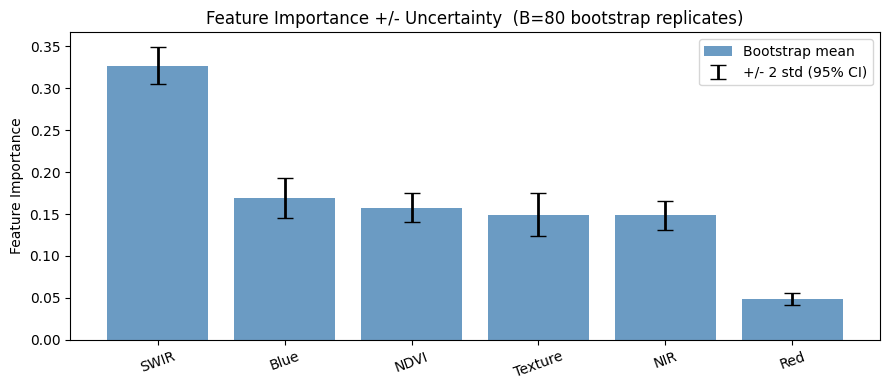

Wide error bars = high variance = don't trust that ranking without more data.


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
idx2 = np.argsort(imp_mean)[::-1]
x_pos = np.arange(n_features)
ax.bar(x_pos, imp_mean[idx2], color='steelblue', alpha=0.8, label='Bootstrap mean')
ax.errorbar(x_pos, imp_mean[idx2], yerr=2*imp_std[idx2],
            fmt='none', color='black', capsize=6, lw=2, label='+/- 2 std (95% CI)')
ax.set_xticks(x_pos)
ax.set_xticklabels([feature_names[i] for i in idx2], rotation=20)
ax.set_ylabel('Feature Importance')
ax.set_title(f'Feature Importance +/- Uncertainty  (B={B} bootstrap replicates)')
ax.legend()
plt.tight_layout(); plt.savefig('importance_variance.png', dpi=100); plt.show()
print("Wide error bars = high variance = don't trust that ranking without more data.")


In [8]:
# SymPy: bootstrap variance formula
B_sym = sp.Symbol('B', positive=True)
I_b   = sp.Symbol('I_b')
I_bar = sp.Symbol('bar_I')
i_sym = sp.Symbol('i', integer=True, positive=True)

boot_var_eq = sp.Eq(sp.Symbol('Var_boot(I)'),
    sp.Sum((I_b - I_bar)**2, (i_sym, 1, B_sym)) / (B_sym - 1))
print("Bootstrap variance of feature importance:")
display(boot_var_eq)

cv_eq = sp.Eq(sp.Symbol('CV'),
              sp.Symbol('sigma_I') / sp.Symbol('mu_I'))
print("Coefficient of variation (instability index):")
display(cv_eq)
print("Rule of thumb: CV > 20% means the ranking is unreliable.")


Bootstrap variance of feature importance:


                B                 
               ___                
               ╲                  
                ╲                2
                ╱   (I_b - bar_I) 
               ╱                  
               ‾‾‾                
              i = 1               
Var_boot(I) = ────────────────────
                     B - 1        

Coefficient of variation (instability index):


     σ_I
CV = ───
     μ_I

Rule of thumb: CV > 20% means the ranking is unreliable.


---
## §4 — Satellite Imaging Parallax: Depth from Two Photos

A satellite takes two photos of the same scene from slightly different positions.
Objects closer to the satellite appear to shift more between images.
This shift is called **parallax** (or **disparity**).

### The geometry — similar triangles

```
    Satellite 1          Satellite 2
         *---------B----------*
         |                    |
         | H (altitude)       | H
         |                    |
         *----d (disparity)---*
              ^  object on ground  ^
```

By **similar triangles** (elementary proportion):

$$\frac{B}{H} = \frac{d}{Z} \;\Longrightarrow\; Z = \frac{B \cdot f}{d}$$

where $B$ = baseline (m), $H$ = altitude (m), $d$ = disparity (pixels),
$f$ = focal length in pixels, $Z$ = depth (distance to object).

This is the **same proportion** from §1.1 — $\frac{a}{b} = \frac{c}{d}$.


In [9]:
B_sym, H_sym, d_sym, f_sym, Z_sym = sp.symbols('B H d f Z', positive=True)

# Parallax equation from similar triangles
parallax_eq = sp.Eq(Z_sym, B_sym * f_sym / d_sym)
print("Parallax depth equation (from similar triangles):"); display(parallax_eq)

# Solve for disparity given depth
d_from_Z = sp.solve(parallax_eq, d_sym)[0]
print("\nDisparity given depth Z:")
display(sp.Eq(d_sym, d_from_Z))

# Numerical example: WorldView-3 satellite stereo
B_val = 45e3      # 45 km baseline between two image captures
H_val = 617e3     # 617 km altitude
f_val = 110e3     # ~110,000 pixel focal length equivalent
print("\nWorldView-3 stereo example:")
print(f"  Baseline B = {B_val/1e3:.0f} km")
print(f"  Altitude H = {H_val/1e3:.0f} km")

for h_obj in [0, 10, 50, 200]:   # object height above ground (m)
    Z_effective = H_val - h_obj
    d_pix = B_val * f_val / (H_val * Z_effective / H_val)
    depth_err = H_val - Z_effective
    parallax_shift = B_val * f_val / H_val**2 * h_obj
    print(f"  Object height {h_obj:4d} m -> parallax shift = {parallax_shift:.2f} pixels")


Parallax depth equation (from similar triangles):


    B⋅f
Z = ───
     d 


Disparity given depth Z:


    B⋅f
d = ───
     Z 


WorldView-3 stereo example:
  Baseline B = 45 km
  Altitude H = 617 km
  Object height    0 m -> parallax shift = 0.00 pixels
  Object height   10 m -> parallax shift = 0.13 pixels
  Object height   50 m -> parallax shift = 0.65 pixels
  Object height  200 m -> parallax shift = 2.60 pixels


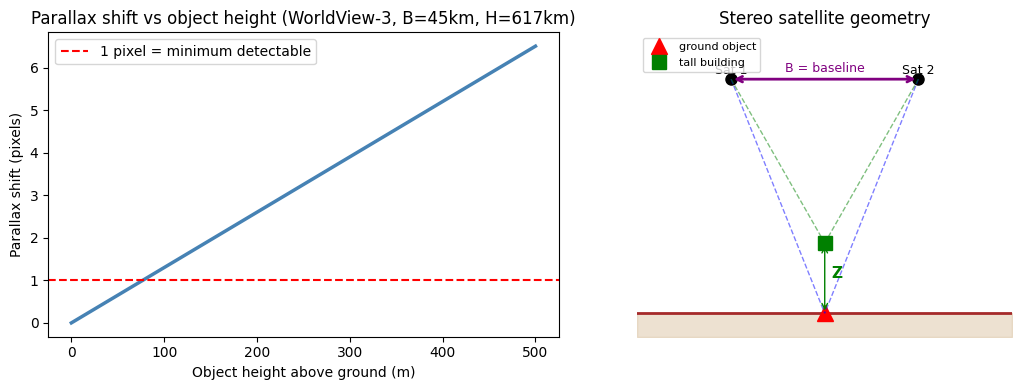

In [10]:
# Visualize: parallax shift vs object height
heights = np.linspace(0, 500, 200)   # object height above ground (m)
# Parallax shift: delta_d = (B * f / H^2) * delta_Z
parallax_factor = B_val * f_val / H_val**2
shifts = parallax_factor * heights

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(heights, shifts, 'steelblue', lw=2.5)
ax1.set_xlabel('Object height above ground (m)')
ax1.set_ylabel('Parallax shift (pixels)')
ax1.set_title('Parallax shift vs object height (WorldView-3, B=45km, H=617km)')
ax1.axhline(1.0, color='red', ls='--', label='1 pixel = minimum detectable')
ax1.legend()

# Cartoon geometry
ax2.set_xlim(-80, 80); ax2.set_ylim(-10, 120)
ax2.set_aspect('equal')
ax2.set_title('Stereo satellite geometry')
# Ground
ax2.axhline(0, color='brown', lw=2)
ax2.fill_between([-80, 80], -10, 0, color='#d2b48c', alpha=0.4)
# Two satellite positions
ax2.plot([-40, 40], [100, 100], 'ko', ms=8)
ax2.annotate('Sat 1', (-40, 102), ha='center', fontsize=9)
ax2.annotate('Sat 2', (40, 102), ha='center', fontsize=9)
ax2.annotate('', xy=(40, 100), xytext=(-40, 100),
             arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax2.text(0, 103, 'B = baseline', ha='center', color='purple', fontsize=9)
# Lines to object
ax2.plot(0, 0, 'r^', ms=12, label='ground object')
ax2.plot(0, 30, 'gs', ms=10, label='tall building')
for x_sat in [-40, 40]:
    ax2.plot([x_sat, 0], [100, 0], 'b--', lw=1, alpha=0.5)
    ax2.plot([x_sat, 0], [100, 30], 'g--', lw=1, alpha=0.5)
ax2.annotate('', xy=(0, 0), xytext=(0, 30),
             arrowprops=dict(arrowstyle='<->', color='green'))
ax2.text(3, 15, 'Z', color='green', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8)
ax2.axis('off')

plt.tight_layout(); plt.savefig('parallax_geometry.png', dpi=100); plt.show()


---
## §5 — Ground Sampling Distance (GSD): How Sharp Is the Image?

**GSD** = the real-world size of one pixel on the ground.

$$\text{GSD} = \frac{H \cdot p}{f}$$

where $p$ = physical pixel pitch (m), $f$ = focal length (m), $H$ = altitude (m).

Same proportion again: $\text{GSD}/H = p/f$.

| Satellite | Altitude | Focal length | Pixel pitch | GSD |
|-----------|----------|-------------|-------------|-----|
| Landsat 8 | 705 km | 886 mm | 14 μm | ~30 m |
| Sentinel-2 | 786 km | 600 mm | 7.5 μm | ~10 m |
| WorldView-3 | 617 km | 3500 mm | 8 μm | 0.31 m |
| PlanetScope | 475 km | 120 mm | 5.5 μm | 2.2 m |


In [11]:
GSD_sym, H_gsd, p_sym, f_gsd = sp.symbols('GSD H p f', positive=True)

gsd_eq = sp.Eq(GSD_sym, H_gsd * p_sym / f_gsd)
print("GSD equation:"); display(gsd_eq)

# Numerical GSD table
satellites = {
    'Landsat 8':    {'H': 705e3, 'f': 0.886, 'p': 14e-6},
    'Sentinel-2':   {'H': 786e3, 'f': 0.600, 'p': 7.5e-6},
    'WorldView-3':  {'H': 617e3, 'f': 3.500, 'p': 8e-6},
    'PlanetScope':  {'H': 475e3, 'f': 0.120, 'p': 5.5e-6},
}

print("\nSatellite GSD comparison:")
print(f"{'Satellite':<15} {'Alt (km)':>9} {'GSD (m)':>9} {'Resolves?':>15}")
print("-"*52)
for name, s in satellites.items():
    gsd = s['H'] * s['p'] / s['f']
    resolves = "car (4m)" if gsd < 4 else ("building (15m)" if gsd < 15 else "field (>15m)")
    print(f"{name:<15} {s['H']/1e3:>9.0f} {gsd:>9.2f} {resolves:>15}")


GSD equation:


      H⋅p
GSD = ───
       f 


Satellite GSD comparison:
Satellite        Alt (km)   GSD (m)       Resolves?
----------------------------------------------------
Landsat 8             705     11.14  building (15m)
Sentinel-2            786      9.83  building (15m)
WorldView-3           617      1.41        car (4m)
PlanetScope           475     21.77    field (>15m)


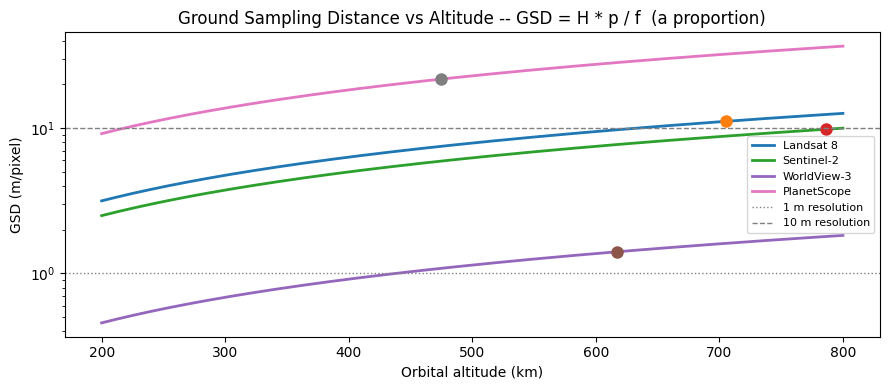

Key insight: GSD is proportional to altitude. Double H -> double GSD (worse resolution).


In [12]:
# GSD vs altitude: proportion is LINEAR
H_vals = np.linspace(200e3, 800e3, 300)

fig, ax = plt.subplots(figsize=(9, 4))
for name, s in satellites.items():
    gsd_vals = H_vals * s['p'] / s['f']
    ax.plot(H_vals/1e3, gsd_vals, lw=2, label=name)
    # Mark actual operating altitude
    gsd_actual = s['H'] * s['p'] / s['f']
    ax.plot(s['H']/1e3, gsd_actual, 'o', ms=8)

ax.axhline(1.0,  color='gray', ls=':', lw=1, label='1 m resolution')
ax.axhline(10.0, color='gray', ls='--', lw=1, label='10 m resolution')
ax.set_xlabel('Orbital altitude (km)')
ax.set_ylabel('GSD (m/pixel)')
ax.set_title('Ground Sampling Distance vs Altitude -- GSD = H * p / f  (a proportion)')
ax.legend(fontsize=8); ax.set_yscale('log')
plt.tight_layout(); plt.savefig('gsd_altitude.png', dpi=100); plt.show()
print("Key insight: GSD is proportional to altitude. Double H -> double GSD (worse resolution).")


---
## §6 — Putting It Together: Classify Land Cover from a Satellite

We now combine everything:
1. A satellite at altitude $H$ gives us pixels of size GSD
2. Each pixel has spectral features (NDVI, NIR, Red, ...)
3. The random forest ranks which spectral band matters most (§2–3)
4. Parallax from stereo imaging adds a height feature — buildings vs trees (§4)

**Full pipeline**: raw satellite image → feature extraction → random forest → land cover map.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# Simulate a 200x200 pixel satellite scene
H_sat = 617e3   # WorldView-3 altitude
GSD   = 0.31    # m/pixel
scene_size = 200

# Generate synthetic 6-band image (NDVI, NIR, Red, Blue, SWIR, Texture)
# Three land cover classes: forest=0, water=1, urban=2
np.random.seed(7)
labels_2d = np.zeros((scene_size, scene_size), dtype=int)
# Forest in top-left quadrant
labels_2d[:100, :100] = 0
# Water in top-right
labels_2d[:100, 100:] = 1
# Urban in bottom half
labels_2d[100:, :] = 2

# Spectral signatures per class (mean reflectance)
class_means = {
    0: [0.7, 0.8, 0.1, 0.05, 0.3, 0.4],   # forest: high NDVI
    1: [0.0, 0.1, 0.05, 0.3, 0.02, 0.1],  # water: high blue, low else
    2: [0.1, 0.3, 0.4, 0.3, 0.5, 0.8],    # urban: high red, SWIR, texture
}

X_scene = np.zeros((scene_size**2, 6))
y_scene = labels_2d.ravel()
for cls, means in class_means.items():
    mask = y_scene == cls
    X_scene[mask] = (rng.normal(0, 0.05, (mask.sum(), 6)) +
                     np.array(means))

X_scene = np.clip(X_scene, 0, 1)

# Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(X_scene, y_scene,
                                           test_size=0.3, random_state=42)
rf_scene = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scene.fit(X_tr, y_tr)
y_pred = rf_scene.predict(X_te)

print("Land cover classification report:")
print(classification_report(y_te, y_pred,
      target_names=['Forest', 'Water', 'Urban']))


Land cover classification report:
              precision    recall  f1-score   support

      Forest       1.00      1.00      1.00      2981
       Water       1.00      1.00      1.00      3016
       Urban       1.00      1.00      1.00      6003

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



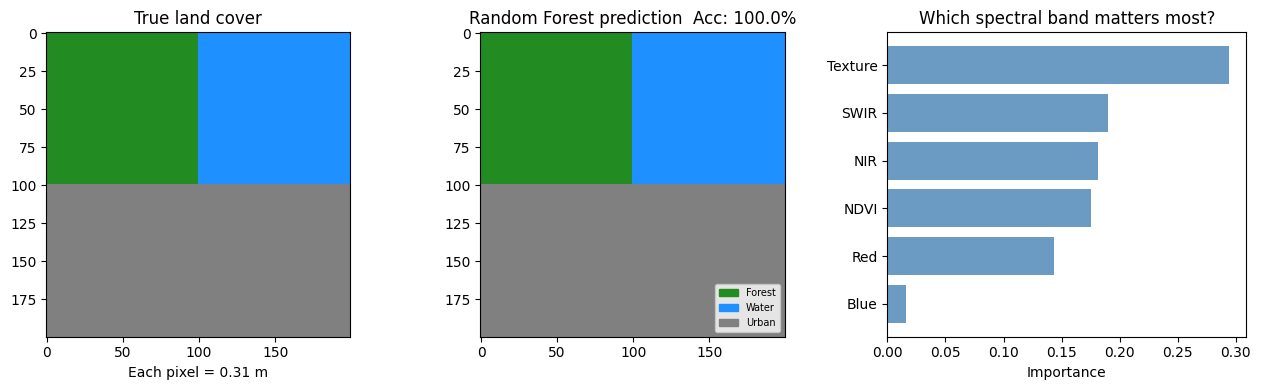

Scene covers 62 x 62 m = 0.00 km^2


In [14]:
# Visualize: true scene, predicted map, feature importance
y_pred_full = rf_scene.predict(X_scene)
pred_map = y_pred_full.reshape(scene_size, scene_size)
true_map = labels_2d

imp_scene = rf_scene.feature_importances_

fig = plt.figure(figsize=(13, 4))

# True map
ax1 = fig.add_subplot(1, 3, 1)
from matplotlib.colors import ListedColormap
cmap3 = ListedColormap(['#228b22', '#1e90ff', '#808080'])
ax1.imshow(true_map, cmap=cmap3, vmin=0, vmax=2, interpolation='nearest')
ax1.set_title('True land cover')
ax1.set_xlabel(f'Each pixel = {GSD:.2f} m')

# Predicted map
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(pred_map, cmap=cmap3, vmin=0, vmax=2, interpolation='nearest')
acc = (pred_map == true_map).mean()
ax2.set_title('Random Forest prediction  Acc: ' + f'{acc:.1%}')
from matplotlib.patches import Patch
legend = [Patch(color='#228b22', label='Forest'),
          Patch(color='#1e90ff', label='Water'),
          Patch(color='#808080', label='Urban')]
ax2.legend(handles=legend, loc='lower right', fontsize=7)

# Feature importance
ax3 = fig.add_subplot(1, 3, 3)
idx3 = np.argsort(imp_scene)
ax3.barh(range(6), imp_scene[idx3], color='steelblue', alpha=0.8)
ax3.set_yticks(range(6))
ax3.set_yticklabels([feature_names[i] for i in idx3])
ax3.set_xlabel('Importance')
ax3.set_title('Which spectral band matters most?')

plt.tight_layout(); plt.savefig('land_cover_pipeline.png', dpi=100); plt.show()

physical_size = scene_size * GSD
print(f"Scene covers {physical_size:.0f} x {physical_size:.0f} m = {physical_size**2/1e6:.2f} km^2")


---
## §7 — All the Algebra, Unified

Every formula in this notebook is a **proportion or a weighted average**.
Elementary algebra is the grammar that all of physics, ML, and remote sensing speaks.


In [15]:
sp.init_printing(use_latex='mathjax')

B_s, H_s, d_s, f_s, Z_s = sp.symbols('B H d f Z', positive=True)
p_s, GSD_s             = sp.symbols('p GSD', positive=True)
I_j, n_v, N_s, Delta_I = sp.symbols('I_j n_v N Delta_I', positive=True)
sigma_I, mu_I, B_boot  = sp.symbols('sigma_I mu_I B', positive=True)

eqs = {
    "Proportion (algebra)":
        sp.Eq(sp.Symbol('a')/sp.Symbol('b'),
              sp.Symbol('c')/sp.Symbol('d')),
    "Parallax depth (stereo sat)":
        sp.Eq(Z_s, B_s * f_s / d_s),
    "GSD (resolution)":
        sp.Eq(GSD_s, H_s * p_s / f_s),
    "Feature importance (RF)":
        sp.Eq(I_j,
              sp.Sum(n_v * Delta_I / N_s,
                     (sp.Symbol('v'), 1, sp.Symbol('T')))),
    "Importance CV (stability)":
        sp.Eq(sp.Symbol('CV'), sigma_I / mu_I),
}

for name, eq in eqs.items():
    print(f"{name}:"); display(eq)


Proportion (algebra):


a   c
─ = ─
b   d

Parallax depth (stereo sat):


    B⋅f
Z = ───
     d 

GSD (resolution):


      H⋅p
GSD = ───
       f 

Feature importance (RF):


       T          
      ____        
      ╲           
       ╲          
        ╲   Δ_I⋅nᵥ
I_j =   ╱   ──────
       ╱      N   
      ╱           
      ‾‾‾‾        
      v = 1       

Importance CV (stability):


     σ_I
CV = ───
     μ_I

---
## Summary

| Concept | Formula | Source |
|---------|---------|--------|
| Proportion | $a/b = c/d$ | Elementary algebra §1 |
| Parallax depth | $Z = Bf/d$ | Similar triangles §4 |
| GSD | $\text{GSD} = Hp/f$ | Proportion §5 |
| Feature importance | weighted Gini reduction | Random forest §2 |
| Bootstrap variance | $\sigma^2 = \frac{1}{B-1}\sum(I_b - \bar I)^2$ | Statistics §3 |

**The thread**: proportions from 9th-grade algebra → stereo satellite imaging
→ feature importance in ML. The same ratio $a/b = c/d$ runs through all of it.
Community college algebra IS the foundation of satellite Earth observation.
